# Code Just for Maps after already saving .tif files in other code

In [17]:
import rasterio
import geopandas as gpd


In [18]:
# States boundary file
states_path = 'D:/ArcGIS/Boundaries/States/conterminous_states_usgs/Conterminous_States_usgs.shp'
states = gpd.read_file(states_path)

In [19]:
# Import tif file
#raster_path = "D:/Data/OASES/Future_NO3/torch_current_preds_COMID_raster_1000m_sw.tif"
#raster_path = "D:/Data/OASES/Future_NO3/torch_image_NUE_preds_COMID_raster_1000m_sw2.tif"

#raster_path = 'D:/Data/OASES/Future_NO3/torch_image_NUE15_preds_COMID_raster_1000m_gw.tif'
#raster_path = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE0_preds_COMID_raster_1000m_gw.tif'
raster_path = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE15_preds_COMID_raster_1000m_gw.tif'
#raster_path = 'D:/Data/OASES/Future_NO3/torch_image_RCP45G_Prod55_NUE0_preds_COMID_raster_1000m_gw.tif'


maptiff = rasterio.open(raster_path)

In [20]:
src = rasterio.open(raster_path)
src.crs, type(src)

(CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'),
 rasterio.io.DatasetReader)

In [21]:
states.crs, type(states)

(<Projected CRS: ESRI:102039>
 Name: USA_Contiguous_Albers_Equal_Area_Conic_USGS_version
 Axis Info [cartesian]:
 - [east]: Easting (metre)
 - [north]: Northing (metre)
 Area of Use:
 - undefined
 Coordinate Operation:
 - name: unnamed
 - method: Albers Equal Area
 Datum: North American Datum 1983
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich,
 geopandas.geodataframe.GeoDataFrame)

In [22]:
# Check if same projection (should say "True")
if states.crs == src.crs:
    print("True")
else: 
    print("False")

True


In [23]:
# Check if they overlap
from shapely.geometry import box

# Create a Shapely polygon from the raster's bounding box
raster_extent = box(*src.bounds)
gdf_extent = box(*states.total_bounds)


has_overlap = raster_extent.intersects(gdf_extent)

print(f"Do the datasets overlap? {has_overlap}")

Do the datasets overlap? True


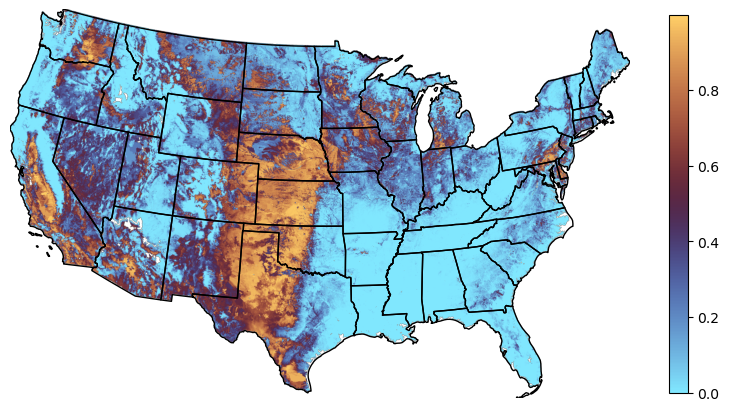

Finished at: 2026-09-16 12:39:28


In [26]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt


# Open your saved TIF file
with rasterio.open(raster_path) as src:
    #print("Band count:", src.count)
    #print("Data type:", src.dtypes)
    #print("Bounds:", src.bounds)

    fig, ax = plt.subplots(figsize=(10, 7))

   # Plot the first band with a grayscale or terrain colormap
    raster_img = show(src, 1, ax=ax, cmap='managua_r')  # Change 'gray' to 'viridis' or 'terrain' if needed

    # This prevents states.plot from resizing the view window away from your image
    raster_bounds = src.bounds
    ax.set_xlim(raster_bounds.left, raster_bounds.right)
    ax.set_ylim(raster_bounds.bottom, raster_bounds.top)
    
    # Extract the image object to construct a matching color bar
    #fig.colorbar(raster_img.get_images()[0], ax=ax, shrink=0.7)#,label="Risk")
    fig.colorbar(ax.images[0], ax=ax, shrink=0.7)

    # Overlay the state boundaries
    if states.crs != src.crs:
        states = states.to_crs(src.crs)
    states.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    ax.set_axis_off()
    plt.show()

# Print current time at the end
from datetime import datetime
print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))